In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io, color, util, filters

def run_laplacian(image_path):
    try:
        fig_3_38 = io.imread(image_path)
        if fig_3_38 is None:
            raise FileNotFoundError("Erro: Imagem da Figura 3.38 não encontrada.")
    except FileNotFoundError as e:
        print(e)
        exit()

    img_original_a = fig_3_38 

    if img_original_a.ndim > 2:
        grayscale_img = color.rgb2gray(img_original_a)
    else:
        grayscale_img = img_original_a

    laplacian_mask = filters.laplace(grayscale_img)

    laplacian_adjusted = laplacian_mask + np.mean(laplacian_mask)

    img_aguçada = grayscale_img - laplacian_mask

    k = 1.0 # Fator de aguçamento. 
    img_aguçada_com_fator = grayscale_img + k * laplacian_mask * (-1)
    img_aguçada_final = grayscale_img - laplacian_mask

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # Imagem Original (recortada)
    axes[0, 0].imshow(grayscale_img, cmap='gray')
    axes[0, 0].set_title('Original Borrada (a)')
    axes[0, 0].axis('off')

    # Laplaciano sem ajuste (similar a 'b')
    axes[0, 1].imshow(laplacian_mask, cmap='gray')
    axes[0, 1].set_title('Laplaciano (Máscara) (similar a b)')
    axes[0, 1].axis('off')

    # Laplaciano com ajuste (similar a 'c')
    axes[1, 0].imshow(laplacian_adjusted, cmap='gray')
    axes[1, 0].set_title('Laplaciano com Ajuste (similar a c)')
    axes[1, 0].axis('off')

    # Imagem Aguçada (similar a 'd' e 'e')
    axes[1, 1].imshow(img_aguçada_final, cmap='gray')
    axes[1, 1].set_title('Imagem Aguçada (similar a d/e)')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    
    # io.imsave('T8-laplaciano_mask.png', util.img_as_float(laplacian_mask))
    # io.imsave('T8-laplaciano_adjusted.png', util.img_as_float(laplacian_adjusted))
    # io.imsave('T8-imagem_agucada.png', util.img_as_float(img_aguçada_final))

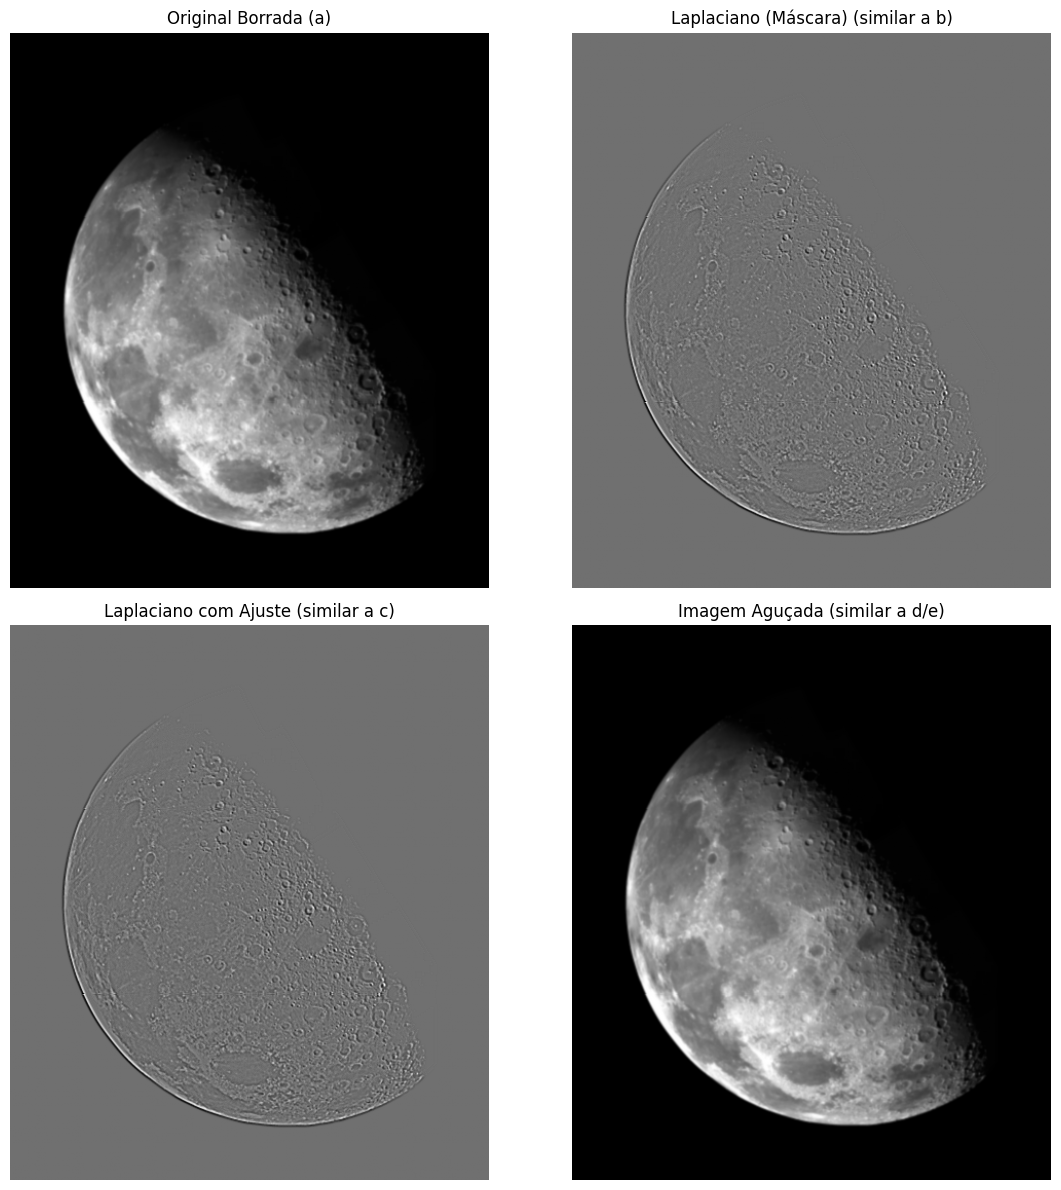

In [11]:
image_path = './images/FIG033_4.TIF'
run_laplacian(image_path)


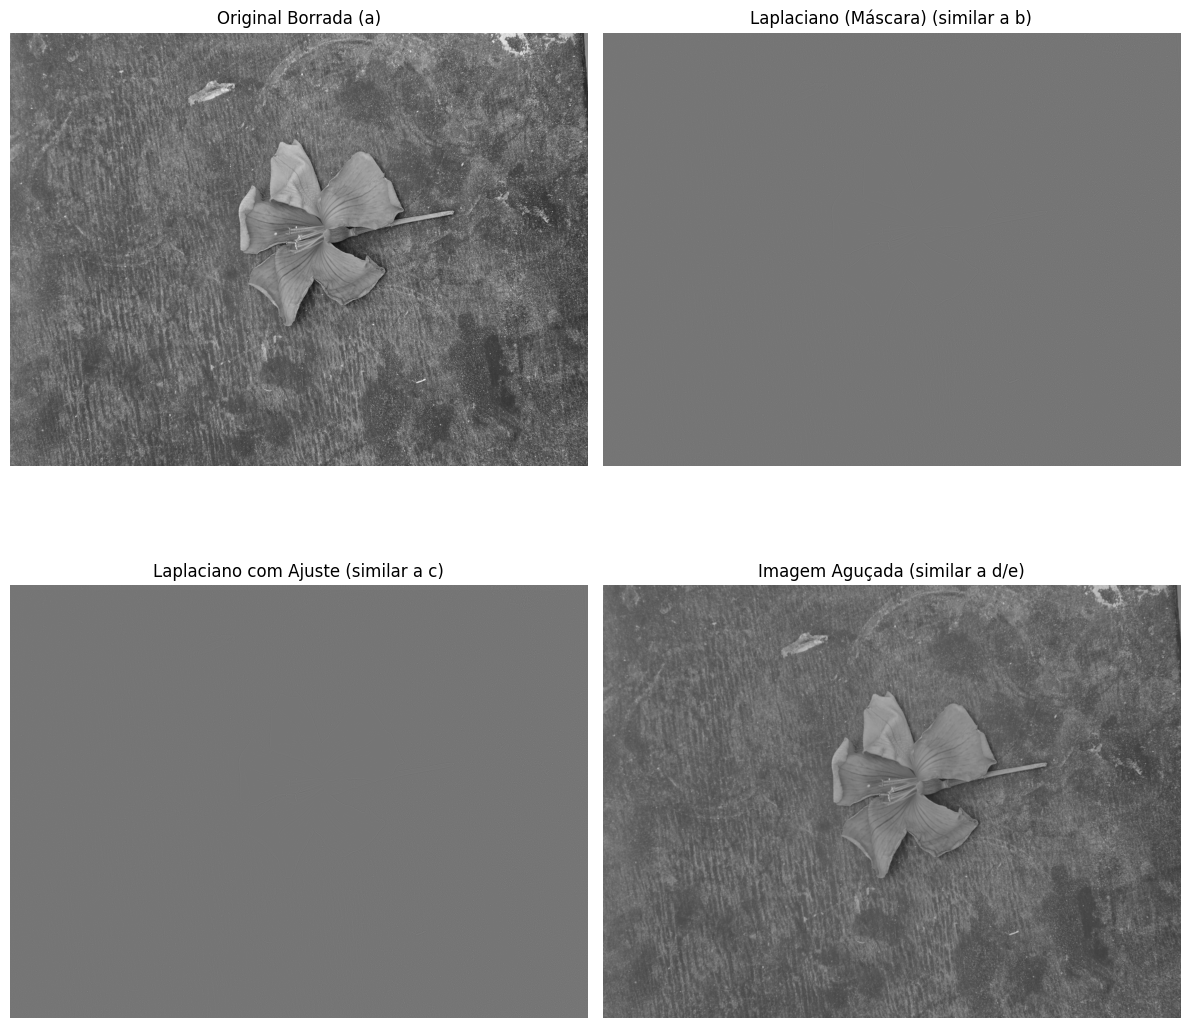

In [15]:
image_path = './images/flor_i_d_01.jpg'
run_laplacian(image_path)